<a href="https://colab.research.google.com/github/JeffersonLin/Real-vs-AI-image-recongition/blob/Caleb/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data Reading

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/4600 Project AI Classification"
DATASET_DIRNAME = "DeepGuardDB_v1"

dataset_root = os.path.join(BASE_DIR, DATASET_DIRNAME)

# Sanity check (optional)
print("Dataset root:", dataset_root)
print("Exists?", os.path.isdir(dataset_root))

# subfolders
FOLDERS = {
    "dalle":  os.path.join(dataset_root, "DALLE_dataset"),
    "glide":  os.path.join(dataset_root, "GLIDE_dataset"),
    "imagen": os.path.join(dataset_root, "IMAGEN_dataset"),
    "sd":     os.path.join(dataset_root, "SD_dataset"),
    "json":   os.path.join(dataset_root, "json_files"),
}

#collect all img files, account for any other image types
def _collect_files(root_dir, exts=(".png", ".jpg", ".jpeg", ".webp")):
    files = []
    if os.path.isdir(root_dir):
        for dirpath, dirnames, filenames in os.walk(root_dir):
            for f in filenames:
                if f.lower().endswith(exts):
                    files.append(os.path.join(dirpath, f))
    return files



def load_all_data():
    data = {}
    for name, root in FOLDERS.items():
        if name == "json":
            continue

        real_dir = os.path.join(root, "real")
        fake_dir = os.path.join(root, "fake")

        real_files = _collect_files(real_dir)
        fake_files = _collect_files(fake_dir)

        data[name] = {"real": real_files, "fake": fake_files}

    return data


def load_dataset(name):
    root = FOLDERS[name]

    if name == "json":
        all_files = []
        for dirpath, dirnames, filenames in os.walk(root):
            for f in filenames:
                all_files.append(os.path.join(dirpath, f))
        return {"all": all_files}

    real_dir = os.path.join(root, "real")
    fake_dir = os.path.join(root, "fake")

    real_files = _collect_files(real_dir)
    fake_files = _collect_files(fake_dir)

    if real_files or fake_files:
        return {"real": real_files, "fake": fake_files}

    all_files = []
    for dirpath, dirnames, filenames in os.walk(root):
        for f in filenames:
            all_files.append(os.path.join(dirpath, f))

    return {"all": all_files}


Mounted at /content/drive
Dataset root: /content/drive/MyDrive/4600 Project AI Classification/DeepGuardDB_v1
Exists? True


# PCA Preprocessing

In [19]:
from PIL import Image
from sklearn.decomposition import PCA
def sample_images(n):

    all_data = load_all_data()
    datasets = ['dalle','glide','imagen','sd']
    all_samples = {}

    for i in datasets:
        real = all_data[i]['real'] #call real 1
        fake = all_data[i]['fake'] #call fake 0
        real_sample = real[:n]
        fake_sample = fake[:n]

        for path in real_sample:
            all_samples[path] =1

        for path in fake_sample:
            all_samples[path] = 0

    return all_samples

def apply_gray_scale_pca(all_samples, size, n_components):
    inputs = []
    labels = []
    for path, label in all_samples.items():
        img = Image.open(path).convert("L")     #gray scale according to my notes below
        img = img.resize(size)                  #512x512
        arr = np.asarray(img) / 255.0           #normalizes
        inputs.append(arr.flatten())            #flattens
        labels.append(label)
    x = np.vstack(inputs) #fpr 2d
    y = np.array(labels, dtype = int)

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    pca_model = PCA(n_components)
    x_pca = pca_model.fit_transform(x_scaled)

    return x_pca, y, scaler, pca_model

def apply_RGB_scale_pca(all_samples, size, n_components):
    inputs = []
    labels = []
    for path, label in all_samples.items():
        img = Image.open(path).convert("RGB")   #RGB scale according to my notes below
        img = img.resize(size)                  #512x512
        arr = np.asarray(img) / 255.0           #normalizes
        inputs.append(arr.flatten())            #flattens
        labels.append(label)
    x = np.vstack(inputs) #fpr 2d
    y = np.array(labels, dtype = int)

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    pca_model = PCA(n_components)
    x_pca = pca_model.fit_transform(x_scaled)

    return x_pca, y, scaler, pca_model

def apply_patch_pca(all_samples, size, patch_size, n_components): #Patch using RGB. Evaluates using local pixels nearby rather than global pixels approach with PCA.
    ph, pw = patch_size

    items = list(all_samples.items())  #(path, label)

    patch_list = []
    patches_per_image = []
    labels = []

    # loop through each img
    for path, label in items:
        img = Image.open(path).convert("RGB") #RGB scale
        img = img.resize(size)
        arr = np.asarray(img) / 255.0

        H, W , C = arr.shape
        #ensure each are returning RGB images

        nrows, ncols = H // ph, W // pw

        arr = arr[:nrows*ph, :ncols*pw]

        count_patches = 0
        for ii in range(nrows):
            for jj in range(ncols):
                block = arr[ii*ph:(ii+1)*ph, jj*pw:(jj+1)*pw, :]
                vec = block.reshape(-1, order='F')
                patch_list.append(vec)
                count_patches += 1

        patches_per_image.append(count_patches)
        labels.append(label)

    X_patches = np.vstack(patch_list)
    y = np.array(labels, dtype=int)

    scaler = StandardScaler()
    X_patches_scaled = scaler.fit_transform(X_patches)

    pca_model = PCA(n_components=n_components)
    X_patches_pca = pca_model.fit_transform(X_patches_scaled)

    num_images = len(items)
    X_img = np.zeros((num_images, n_components))

    # combine the imgs back together
    idx = 0
    for i in range(num_images):
        m = patches_per_image[i]           # how many patches in this image
        feat_patches = X_patches_pca[idx:idx+m]  # (m, n_components)
        X_img[i, :] = feat_patches.mean(axis=0)
        idx += m

    return X_img, y, scaler, pca_model

In [21]:
# training file for the knn model
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression



def run_knn(x, y, n_neighbors=5):
    data = load_all_data()

    dalle_real = data["dalle"]["real"]
    dalle_fake = data["dalle"]["fake"]

    # print("Dalle REAL images:", len(dalle_real))
    # print("Dalle FAKE images:", len(dalle_fake))

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean", weights="uniform")
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    print("KNN accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

    return knn

def run_logistic_regression(x, y):
    data = load_all_data()

    dalle_real = data["dalle"]["real"]
    dalle_fake = data["dalle"]["fake"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    LR = LogisticRegression(max_iter=1000, penalty = "l2", C = 1.0, solver = 'lbfgs')
    LR.fit(x_train,y_train)

    y_pred = LR.predict(x_test)

    print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))

    return LR




if __name__ == "__main__":
    samples = sample_images(20)

    x_gray_pca, y, gray_scaler, gray_pca_model = apply_gray_scale_pca(samples, size = (128,128), n_components=50)
    # print("PCA shape:", x_pca.shape)
    # print("y shape:", y.shape)

    x_rgb_pca, y, rgb_scaler, RGB_pca_model = apply_RGB_scale_pca(samples, size = (128,128), n_components=50)
    # print("PCA shape:", x_pca.shape)
    # print("y shape:", y.shape)

    x_patch_pca, y, patch_scaler, patch_pca_model = apply_patch_pca(samples, size=(128, 128), patch_size=(8, 8), n_components=50)
    # print("Patch-PCA feature shape:", x_patch_pca.shape)
    # print("Labels shape:", y.shape)

    knn_model = run_knn(x_patch_pca, y, n_neighbors=5)
    knn_model_2 = run_knn(x_gray_pca, y, n_neighbors=5)
    knn_model_3 = run_knn(x_rgb_pca, y, n_neighbors=5)

    LR_gray  = run_logistic_regression(x_gray_pca, y)
    LR_rgb   = run_logistic_regression(x_rgb_pca, y)
    LR_patch = run_logistic_regression(x_patch_pca, y)

#dictionary to classify what dataset it came from
# do a pca transformation channel by channel. so we treat each column channel as an independent gary scale image.

KNN accuracy: 0.59375
Confusion matrix:
 [[ 9  7]
 [ 6 10]]
Classification report:
               precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32

KNN accuracy: 0.59375
Confusion matrix:
 [[ 8  8]
 [ 5 11]]
Classification report:
               precision    recall  f1-score   support

           0       0.62      0.50      0.55        16
           1       0.58      0.69      0.63        16

    accuracy                           0.59        32
   macro avg       0.60      0.59      0.59        32
weighted avg       0.60      0.59      0.59        32

KNN accuracy: 0.5
Confusion matrix:
 [[ 5 11]
 [ 5 11]]
Classification report:
               precision    recall  f1-score   support

           0       0.50      0.31      0.38

# Image Reconstruction

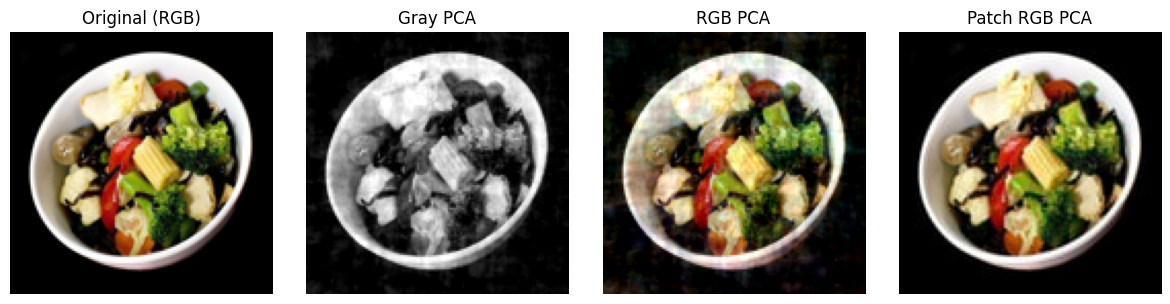

In [18]:
import matplotlib.pyplot as plt
def reconstruct_gray_from_pca(path, size, scaler, pca_model):
    img = Image.open(path).convert("L")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    H, W = arr.shape

    x = arr.flatten()[None, :]
    x_scaled = scaler.transform(x)
    z = pca_model.transform(x_scaled)
    x_scaled_rec = z @ pca_model.components_ + pca_model.mean_
    x_rec = scaler.inverse_transform(x_scaled_rec)
    arr_rec = x_rec.reshape(H, W)
    arr_rec = np.clip(arr_rec, 0.0, 1.0)
    return arr_rec


def reconstruct_rgb_from_pca(path, size, scaler, pca_model):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    H, W, C = arr.shape

    x = arr.flatten()[None, :]
    x_scaled = scaler.transform(x)
    z = pca_model.transform(x_scaled)
    x_scaled_rec = z @ pca_model.components_ + pca_model.mean_
    x_rec = scaler.inverse_transform(x_scaled_rec)
    arr_rec = x_rec.reshape(H, W, C)
    arr_rec = np.clip(arr_rec, 0.0, 1.0)
    return arr_rec


def reconstruct_patch_from_pca(path, size, patch_size, scaler, pca_model):
    ph, pw = patch_size
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    H, W, C = arr.shape
    nrows, ncols = H // ph, W // pw
    arr = arr[: nrows * ph, : ncols * pw, :]

    patches = []
    for ii in range(nrows):
        for jj in range(ncols):
            block = arr[ii * ph : (ii + 1) * ph,
                        jj * pw : (jj + 1) * pw,
                        :]
            patches.append(block.reshape(-1, order="F"))

    X = np.vstack(patches)
    X_scaled = scaler.transform(X)
    Z = pca_model.transform(X_scaled)

    X_scaled_rec = Z @ pca_model.components_ + pca_model.mean_
    X_rec = scaler.inverse_transform(X_scaled_rec)

    rec = np.zeros_like(arr)
    idx = 0
    for ii in range(nrows):
        for jj in range(ncols):
            vec = X_rec[idx]
            block = vec.reshape(ph, pw, 3, order="F")
            rec[ii * ph : (ii + 1) * ph,
                jj * pw : (jj + 1) * pw,
                :] = block
            idx += 1

    rec = np.clip(rec, 0.0, 1.0)
    return rec
first_path = list(samples.keys())[0]

if __name__ == "__main__":
    # Original RGB image
    orig_img = Image.open(first_path).convert("RGB").resize((128, 128))
    orig_arr = np.asarray(orig_img, dtype=np.float32) / 255.0

    # Reconstructions
    rec_gray = reconstruct_gray_from_pca(first_path, (128, 128),
                                         gray_scaler, gray_pca_model)
    rec_rgb = reconstruct_rgb_from_pca(first_path, (128, 128),
                                       rgb_scaler, RGB_pca_model)
    rec_patch = reconstruct_patch_from_pca(first_path, (128, 128),
                                           (8, 8), patch_scaler, patch_pca_model)

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 4, 1)
    plt.title("Original (RGB)")
    plt.imshow(orig_arr)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Gray PCA")
    plt.imshow(rec_gray, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("RGB PCA")
    plt.imshow(rec_rgb)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Patch RGB PCA")
    plt.imshow(rec_patch)
    plt.axis("off")

    plt.tight_layout()
    plt.show()